# <span style="color:orange">Planet Level predictions </span>

In [11]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json

ROOT        = Path('..').resolve()
RESULTS_DIR = ROOT / 'results' / 'processed'
CLASS_DIR   = ROOT / 'results' / 'classification'

y_true    = np.load(RESULTS_DIR / 'test_targets.npy')        # (N, 12) true log10 VMR
rf_pred   = np.load(RESULTS_DIR / 'baseline_test_pred.npy')  # (N, 12) RF predicted
deep_pred = np.load(RESULTS_DIR / 'deep_test_pred.npy')      # (N, 12) CNN predicted

with open(CLASS_DIR / 'classification_meta.json') as f:
    meta = json.load(f)

MOLS       = meta['molecules']   # 12 molecule names
ABSENT_THR = meta['thresholds']['absent']   # -39
TRACE_THR  = meta['thresholds']['trace']    # -9

CLASS_NAMES  = ['Absent', 'Trace', 'Significant']
CLASS_COLORS = {'Absent': '#D32F2F', 'Trace': '#F57C00', 'Significant': '#1976D2'}

def assign_class(val):
    if val <= ABSENT_THR:              return 'Absent'
    elif val <= TRACE_THR:             return 'Trace'
    else:                              return 'Significant'

N = y_true.shape[0]
print(f'Test set: {N} planets  x  {len(MOLS)} molecules')
print(f'Thresholds — Absent: ≤{ABSENT_THR}  |  Trace: ({ABSENT_THR}, {TRACE_THR}]  |  Significant: > {TRACE_THR}')


Test set: 18600 planets  x  12 molecules
Thresholds — Absent: ≤-39.0  |  Trace: (-39.0, -9.0]  |  Significant: > -9.0


## 1. Single Planet Profile — CNN Predictions

Pick any planet by its test-set index.  
The bar chart shows **what the CNN predicts** for all 12 molecules,  
alongside the true values — coloured by the 3-class category.


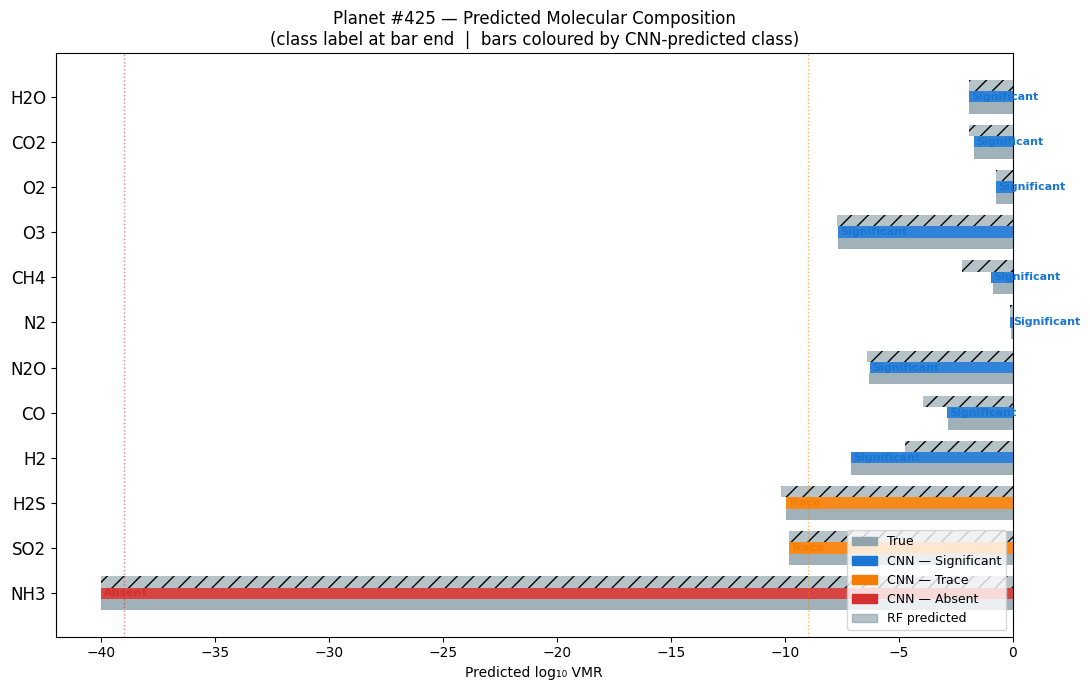


Planet #425 — per-molecule breakdown:
Mol        True       CNN        RF  Class  CNN-err
-------------------------------------------------------
H2O     -1.9101   -1.9101   -1.9100  Significant   0.0000
CO2     -1.6990   -1.7074   -1.9235  Significant   0.0084
O2      -0.7447   -0.7197   -0.7557  Significant   0.0250
O3      -7.6778   -7.6754   -7.7175  Significant   0.0024
CH4     -0.8861   -0.9524   -2.2067  Significant   0.0664
N2      -0.0921   -0.0990   -0.1198  Significant   0.0070
N2O     -6.3197   -6.2867   -6.4150  Significant   0.0329
CO      -2.8297   -2.8884   -3.9214  Significant   0.0587
H2      -7.0899   -7.0985   -4.7426  Significant   0.0086
H2S     -9.9393   -9.9612  -10.1528  Trace         0.0219
SO2     -9.8356   -9.8393   -9.8133  Trace         0.0036
NH3    -40.0000  -40.0000  -40.0000  Absent        0.0000


In [12]:
# ── Change this to inspect any planet ────────────────────────────────────
PLANET_IDX = 425   # try: 0, 425, 588, 1811, 6200, 12280
# ─────────────────────────────────────────────────────────────────────────

true_vals = y_true[PLANET_IDX]      # shape (12,)
cnn_vals  = deep_pred[PLANET_IDX]   # shape (12,)
rf_vals   = rf_pred[PLANET_IDX]     # shape (12,)

bar_colors = [CLASS_COLORS[assign_class(v)] for v in cnn_vals]

y    = np.arange(len(MOLS))
h    = 0.25

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(y + h,   true_vals, h, color='#90A4AE', alpha=0.85, label='True')
ax.barh(y,       cnn_vals,  h, color=bar_colors, alpha=0.90, label='CNN predicted')
ax.barh(y - h,   rf_vals,   h, color='#78909C',  alpha=0.55, label='RF predicted', hatch='//')

# Class label at end of each CNN bar
for yi, (cval, col) in enumerate(zip(cnn_vals, bar_colors)):
    cls = assign_class(cval)
    ax.text(cval + 0.1, yi, cls,
            ha='left', va='center', fontsize=8, color=col, fontweight='bold')

# Threshold lines
ax.axvline(ABSENT_THR, color='#D32F2F', lw=1.0, ls=':', alpha=0.6, label='Absent thr (−39)')
ax.axvline(TRACE_THR,  color='#F57C00', lw=1.0, ls=':', alpha=0.6, label='Trace thr (−9)')

ax.set_yticks(y)
ax.set_yticklabels(MOLS, fontsize=12)
ax.invert_yaxis()
ax.set_xlabel('Predicted log₁₀ VMR')
ax.set_title(f'Planet #{PLANET_IDX} — Predicted Molecular Composition\n'
             f'(class label at bar end  |  bars coloured by CNN-predicted class)',
             fontsize=12)

legend_handles = [
    mpatches.Patch(color='#90A4AE', label='True'),
    mpatches.Patch(color='#1976D2', label='CNN — Significant'),
    mpatches.Patch(color='#F57C00', label='CNN — Trace'),
    mpatches.Patch(color='#D32F2F', label='CNN — Absent'),
    mpatches.Patch(color='#78909C', alpha=0.55, label='RF predicted'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

# Print the per-molecule table for this planet
print(f'\nPlanet #{PLANET_IDX} — per-molecule breakdown:')
print('%-5s  %8s  %8s  %8s  %5s  CNN-err' % ('Mol','True','CNN','RF','Class'))
print('-'*55)
for i, m in enumerate(MOLS):
    cc = assign_class(cnn_vals[i])
    print('%-5s  %8.4f  %8.4f  %8.4f  %-12s  %.4f' % (
        m, true_vals[i], cnn_vals[i], rf_vals[i], cc,
        abs(cnn_vals[i]-true_vals[i])))


## 2. Compare 6 Diverse Planets Side by Side

Planets selected to represent different atmospheric regimes:
- **High CH₄** (strongly reducing atmosphere)
- **Low CH₄** (oxidising atmosphere)
- **High H₂** (hydrogen-rich)
- **Low H₂** (hydrogen-poor)
- **Two median** atmospheric compositions


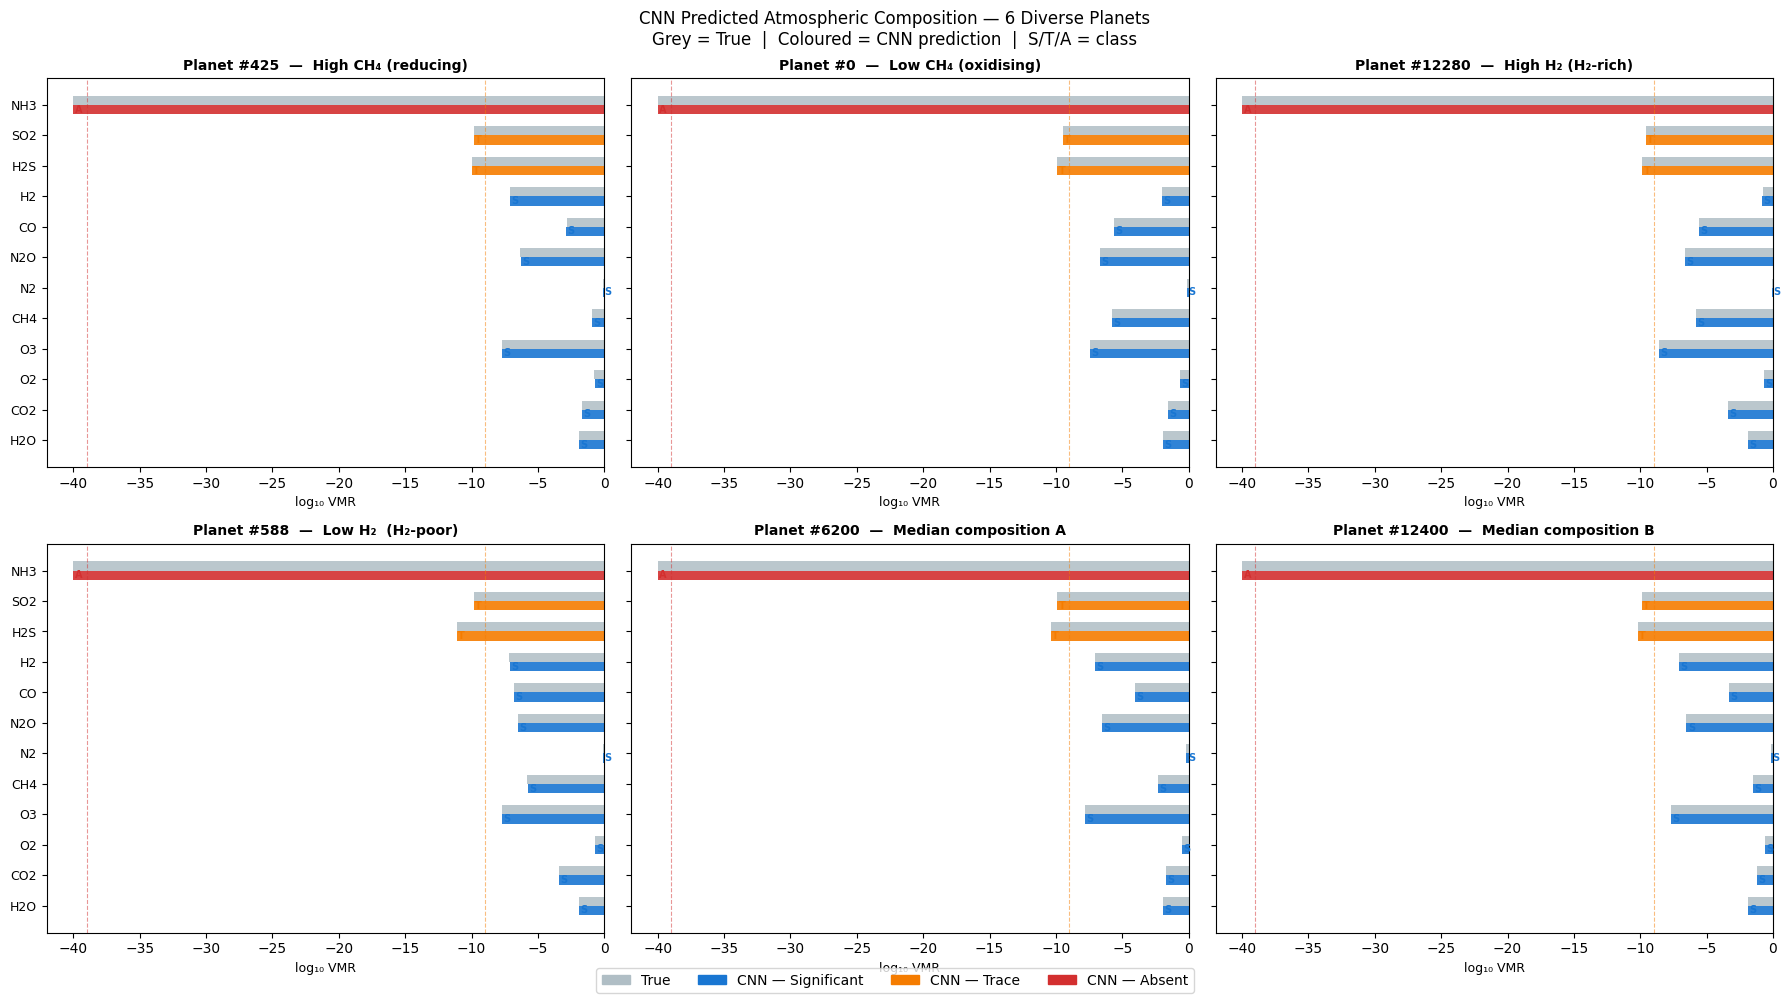

In [13]:
# Pick diverse planets based on CH4 and H2 variation
ch4_sorted = np.argsort(y_true[:, 4])   # CH4 index=4
h2_sorted  = np.argsort(y_true[:, 8])   # H2  index=8
n = len(y_true)

planet_set = [
    (ch4_sorted[-1],  'High CH₄ (reducing)'),
    (ch4_sorted[0],   'Low CH₄ (oxidising)'),
    (h2_sorted[-1],   'High H₂ (H₂-rich)'),
    (h2_sorted[0],    'Low H₂  (H₂-poor)'),
    (n // 3,          'Median composition A'),
    (2 * n // 3,      'Median composition B'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()
y = np.arange(len(MOLS))
h = 0.30

for ax, (pidx, label) in zip(axes, planet_set):
    cnn_vals  = deep_pred[pidx]
    true_vals = y_true[pidx]
    bar_colors = [CLASS_COLORS[assign_class(v)] for v in cnn_vals]

    ax.barh(y + h/2, true_vals, h, color='#B0BEC5', alpha=0.85)
    ax.barh(y - h/2, cnn_vals,  h, color=bar_colors, alpha=0.90)

    ax.axvline(TRACE_THR,  color='#F57C00', lw=0.8, ls='--', alpha=0.5)
    ax.axvline(ABSENT_THR, color='#D32F2F', lw=0.8, ls='--', alpha=0.5)

    ax.set_yticks(y)
    ax.set_yticklabels(MOLS, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('log₁₀ VMR', fontsize=9)
    ax.set_title(f'Planet #{pidx}  —  {label}', fontsize=10, fontweight='bold')

    # Class label at end of CNN bar
    for yi, v in enumerate(cnn_vals):
        cls = assign_class(v)
        col = CLASS_COLORS[cls]
        ax.text(v + 0.1, yi - h/2, cls[0],
                ha='left', va='center', fontsize=7, color=col, fontweight='bold')

legend_handles = [
    mpatches.Patch(color='#B0BEC5', label='True'),
    mpatches.Patch(color='#1976D2', label='CNN — Significant'),
    mpatches.Patch(color='#F57C00', label='CNN — Trace'),
    mpatches.Patch(color='#D32F2F', label='CNN — Absent'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('CNN Predicted Atmospheric Composition — 6 Diverse Planets\n'
             'Grey = True  |  Coloured = CNN prediction  |  S/T/A = class',
             fontsize=12)
plt.tight_layout()
plt.show()


## 3. Heatmap — 200 Planets × 12 Molecules (CNN Predicted Class)

Each row is one planet, each column is one molecule.  
Cell colour = **CNN-predicted class** (not true value — this is what the model says about each planet).
Planets are sorted by their predicted CH₄ concentration.


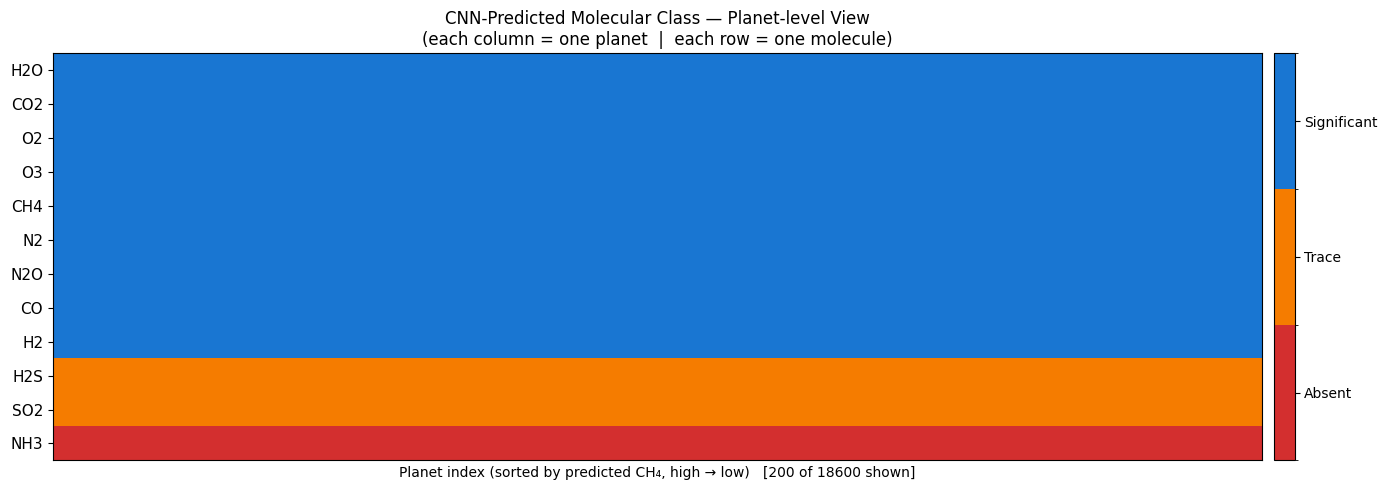

Class variation across the 200 shown planets:
  H2O  : Significant
  CO2  : Significant
  O2   : Significant
  O3   : Significant
  CH4  : Significant
  N2   : Significant
  N2O  : Significant
  CO   : Significant
  H2   : Significant
  H2S  : Trace
  SO2  : Trace
  NH3  : Absent


In [14]:
from matplotlib.colors import ListedColormap, BoundaryNorm

N_SHOW = 200
# Sort planets by CNN-predicted CH4 so similar atmospheres cluster
sort_order = np.argsort(deep_pred[:, 4])[::-1][:N_SHOW]

CLASS_INT = {'Absent': 0, 'Trace': 1, 'Significant': 2}
# class_matrix: (N_SHOW, 12)  →  transpose to (12, N_SHOW) so molecules = rows
class_matrix = np.zeros((N_SHOW, len(MOLS)), dtype=int)
for row_i, pidx in enumerate(sort_order):
    for col_i in range(len(MOLS)):
        class_matrix[row_i, col_i] = CLASS_INT[assign_class(deep_pred[pidx, col_i])]

class_matrix_T = class_matrix.T   # (12 molecules, N_SHOW planets)

cmap = ListedColormap(['#D32F2F', '#F57C00', '#1976D2'])   # Absent / Trace / Significant
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(class_matrix_T, aspect='auto', cmap=cmap, norm=norm,
               interpolation='nearest')

# Molecules on y-axis (rows), planets on x-axis (columns)
ax.set_yticks(range(len(MOLS)))
ax.set_yticklabels(MOLS, fontsize=11)
ax.set_xlabel(f'Planet index (sorted by predicted CH₄, high → low)   [{N_SHOW} of {N} shown]')
ax.set_title('CNN-Predicted Molecular Class — Planet-level View\n'
             '(each column = one planet  |  each row = one molecule)', fontsize=12)
ax.set_xticks([])

cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2], fraction=0.02, pad=0.01)
cbar.ax.set_yticklabels(['Absent', 'Trace', 'Significant'], fontsize=10)
plt.tight_layout()
plt.show()

print('Class variation across the 200 shown planets:')
for j, m in enumerate(MOLS):
    unique = np.unique(class_matrix_T[j])
    print(f'  {m:<5}: {", ".join([CLASS_NAMES[u] for u in unique])}')


## 4. Planet Prediction Table — from CSV

The full predictions for all 18,600 planets are saved to:  
`results/classification/planet_predictions.csv`  
Columns: `planet_idx | {MOL}_true | {MOL}_cnn | {MOL}_rf | {MOL}_class` for each of 12 molecules.

The cell below loads the CSV and shows a configurable sample.


In [15]:
# ── Tune these ───────────────────────────────────────────────────────────
sort_mol  = 'CH4'       # molecule to sort by: H2O CO2 O2 O3 CH4 N2 N2O CO H2 H2S SO2 NH3
sort_col  = 'cnn'       # 'true', 'cnn', or 'rf'
n_sample  = 20          # how many rows to display
ascending = False       # False = highest values first
# ─────────────────────────────────────────────────────────────────────────

df_all = pd.read_csv(CLASS_DIR / 'planet_predictions.csv')
df = (df_all
      .sort_values(f'{sort_mol}_{sort_col}', ascending=ascending)
      .head(n_sample)
      .reset_index(drop=True))

# Show only the columns that matter: idx + per-molecule (cnn value + class)
display_cols = ['planet_idx']
for m in MOLS:
    display_cols += [f'{m}_true', f'{m}_cnn', f'{m}_class']

cls_cols = [c for c in display_cols if c.endswith('_class')]

def color_cls(val):
    return {
        'Significant': 'background-color:#BBDEFB;color:#0D47A1',
        'Trace':       'background-color:#FFE0B2;color:#E65100',
        'Absent':      'background-color:#FFCDD2;color:#B71C1C',
    }.get(val, '')

print(f'Top {n_sample} planets sorted by {sort_mol}_{sort_col} (ascending={ascending})')
display(df[display_cols].style.applymap(color_cls, subset=cls_cols))


Top 20 planets sorted by CH4_cnn (ascending=False)


/var/folders/xf/tmvw9nzd6lb5ct87w5pzymmc0000gn/T/ipykernel_64847/693012989.py:29: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(df[display_cols].style.applymap(color_cls, subset=cls_cols))


,planet_idx,H2O_true,H2O_cnn,H2O_class,CO2_true,CO2_cnn,CO2_class,O2_true,O2_cnn,O2_class,O3_true,O3_cnn,O3_class,CH4_true,CH4_cnn,CH4_class,N2_true,N2_cnn,N2_class,N2O_true,N2O_cnn,N2O_class,CO_true,CO_cnn,CO_class,H2_true,H2_cnn,H2_class,H2S_true,H2S_cnn,H2S_class,SO2_true,SO2_cnn,SO2_class,NH3_true,NH3_cnn,NH3_class
0,14807,-1.910100,-1.910100,Significant,-2.000000,-2.004300,Significant,-0.602100,-0.586500,Significant,-7.655600,-7.652100,Significant,-0.958600,-0.951700,Significant,-0.131200,-0.136600,Significant,-6.189800,-6.201600,Significant,-2.886100,-2.893100,Significant,-7.089900,-7.112200,Significant,-9.974700,-9.979600,Trace,-9.844700,-9.844600,Trace,-40.000000,-40.000000,Absent
1,425,-1.910100,-1.910100,Significant,-1.699000,-1.707400,Significant,-0.744700,-0.719700,Significant,-7.677800,-7.675400,Significant,-0.886100,-0.952400,Significant,-0.092100,-0.099000,Significant,-6.319700,-6.286700,Significant,-2.829700,-2.888400,Significant,-7.089900,-7.098500,Significant,-9.939300,-9.961200,Trace,-9.835600,-9.839300,Trace,-40.000000,-40.000000,Absent
2,13728,-1.910100,-1.910100,Significant,-1.221800,-1.230000,Significant,-0.677800,-0.685100,Significant,-7.638300,-7.661300,Significant,-0.958600,-0.953400,Significant,-0.108300,-0.107900,Significant,-6.287400,-6.296100,Significant,-2.910100,-2.877800,Significant,-1.699000,-6.800900,Significant,-9.950800,-9.961200,Trace,-9.829700,-9.835400,Trace,-40.000000,-40.000000,Absent
3,1467,-1.910100,-1.910100,Significant,-1.397900,-1.391400,Significant,-0.657600,-0.682900,Significant,-7.663500,-7.664200,Significant,-0.920800,-0.956500,Significant,-0.114000,-0.108400,Significant,-6.279000,-6.294000,Significant,-2.853900,-2.877300,Significant,-7.089900,-7.012500,Significant,-9.958600,-9.963900,Trace,-9.835600,-9.838800,Trace,-40.000000,-40.000000,Absent
4,6732,-1.910100,-1.910100,Significant,-1.397900,-1.414100,Significant,-0.699000,-0.696600,Significant,-7.669600,-7.660200,Significant,-0.958600,-0.962500,Significant,-0.102800,-0.104100,Significant,-6.312500,-6.308200,Significant,-2.886100,-2.897900,Significant,-7.089900,-4.241800,Significant,-9.970600,-9.965700,Trace,-9.838600,-9.837600,Trace,-40.000000,-40.000000,Absent
5,9116,-1.910100,-1.910100,Significant,-1.301000,-1.322600,Significant,-0.677800,-0.686900,Significant,-7.651700,-7.661500,Significant,-0.958600,-0.964200,Significant,-0.108400,-0.107700,Significant,-6.293300,-6.297700,Significant,-2.899600,-2.888000,Significant,-2.000000,-6.908100,Significant,-9.962600,-9.970700,Trace,-9.835600,-9.838100,Trace,-40.000000,-40.000000,Absent
6,3231,-1.910100,-1.910100,Significant,-1.397900,-1.392800,Significant,-0.699000,-0.700300,Significant,-7.640200,-7.667800,Significant,-1.000000,-0.965200,Significant,-0.102800,-0.102400,Significant,-6.309800,-6.301900,Significant,-2.946900,-2.891200,Significant,-1.699000,-6.796300,Significant,-9.966600,-9.963400,Trace,-9.835600,-9.838700,Trace,-40.000000,-40.000000,Absent
7,14455,-1.910100,-1.910100,Significant,-1.522900,-1.566500,Significant,-0.677800,-0.691900,Significant,-7.667600,-7.665100,Significant,-0.958600,-0.971100,Significant,-0.108400,-0.105500,Significant,-6.296700,-6.300000,Significant,-2.886100,-2.898100,Significant,-7.089900,-6.755900,Significant,-9.974700,-9.967000,Trace,-9.841600,-9.841000,Trace,-40.000000,-40.000000,Absent
8,4693,-1.910100,-1.910100,Significant,-1.522900,-1.568100,Significant,-0.657600,-0.688100,Significant,-7.636400,-7.647400,Significant,-0.958600,-0.973800,Significant,-0.113900,-0.107800,Significant,-6.276500,-6.287100,Significant,-2.910100,-2.916600,Significant,-1.699000,-2.538000,Significant,-9.950800,-9.967000,Trace,-9.832700,-9.838400,Trace,-40.000000,-40.000000,Absent
9,6538,-1.910100,-1.910100,Significant,-1.522900,-1.593100,Significant,-0.699000,-0.708700,Significant,-7.669600,-7.664200,Significant,-0.958600,-0.975400,Significant,-0.102800,-0.101200,Significant,-6.315200,-6.312000,Significant,-2.886100,-2.907400,Significant,-7.089900,-5.930800,Significan